# Credit-Card Fraud Detection on Highly Imbalanced Data

A worked study of credit-card fraud detection that treats the **0.17% class imbalance as the
central problem**. It reproduces the most common methodological mistake in public fraud
notebooks (resampling *before* the train/test split), then shows what defensible numbers look
like.

This notebook is a thin narrative layer over the [`fraud_detection`](../src/fraud_detection)
package: data loading, splitting, models, calibration, thresholding, metrics, and plots all
come from `src/`. The heavy hyper-parameter search lives in `make train`; here we keep tuning
off so the notebook runs top-to-bottom in a few minutes.

## 1. Setup

In [1]:
%matplotlib inline
import os, warnings
warnings.filterwarnings("ignore")
# Run from the repo root so config/data paths resolve regardless of where Jupyter started.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fraud_detection
from fraud_detection.config import Config
from fraud_detection import data as fd_data, features, evaluation, threshold, calibration, plotting
from fraud_detection.models import (
    MODEL_LABELS, build_supervised_models, scale_pos_weight, make_isolation_forest)
from fraud_detection.tuning import tune

plt.rcParams["figure.figsize"] = (8, 5)
cfg = Config.from_yaml("config/default.yaml")
cfg.tuning.enabled = False   # keep the notebook fast; `make train` runs the tuned search
print("fraud_detection", fraud_detection.__version__, "| seed", cfg.seed)

fraud_detection 0.1.0 | seed 42


## 2. Load the data
Fetched reproducibly from OpenML (no Kaggle login). Run `make data` first if this errors.

In [2]:
df = fd_data.load_data(cfg)
n, n_fraud = len(df), int(df["Class"].sum())
print(f"Transactions : {n:,}")
print(f"Fraudulent   : {n_fraud:,}  ({100*n_fraud/n:.3f}%)")
print(f"Imbalance    : ~1 fraud per {round((n-n_fraud)/n_fraud):,} legitimate transactions")
df.head()

Transactions : 284,807
Fraudulent   : 492  (0.173%)
Imbalance    : ~1 fraud per 578 legitimate transactions


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory data analysis
Accuracy is meaningless at 0.17% positives, so we look at where the fraud signal lives.

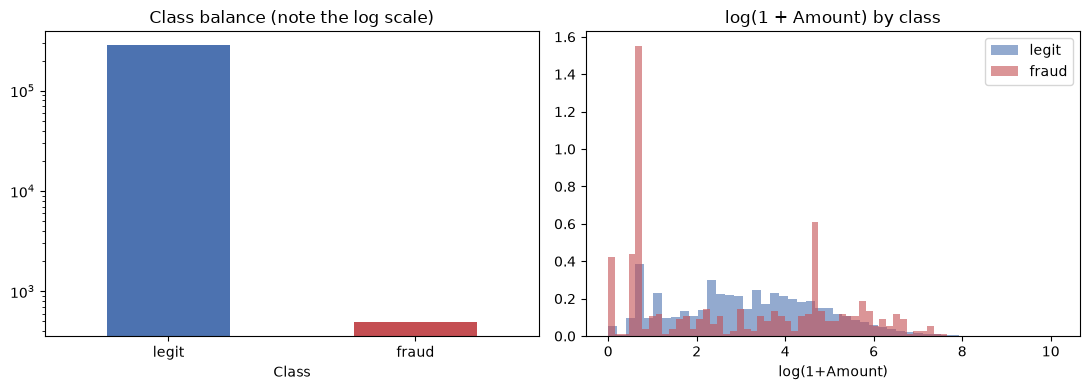

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["Class"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Class balance (note the log scale)"); ax[0].set_yscale("log")
ax[0].set_xticklabels(["legit", "fraud"], rotation=0)
for cls, color, label in [(0, "#4C72B0", "legit"), (1, "#C44E52", "fraud")]:
    ax[1].hist(np.log1p(df.loc[df.Class == cls, "Amount"]), bins=50, alpha=0.6,
               color=color, density=True, label=label)
ax[1].set_title("log(1 + Amount) by class"); ax[1].set_xlabel("log(1+Amount)"); ax[1].legend()
plt.tight_layout(); plt.show()

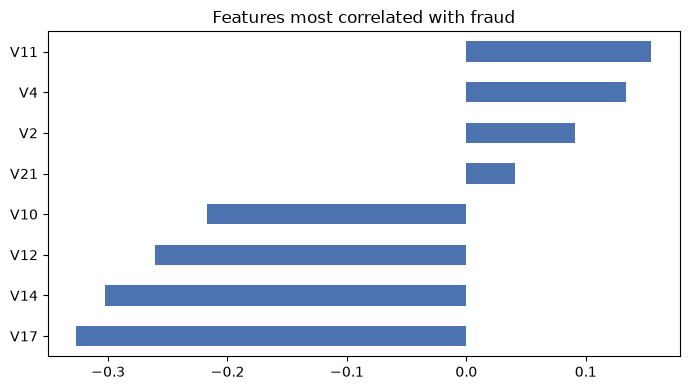

In [4]:
corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values()
top = pd.concat([corr.head(4), corr.tail(4)])
top.plot(kind="barh", color="#4C72B0", figsize=(7, 4),
         title="Features most correlated with fraud")
plt.tight_layout(); plt.show()

## 4. The leakage trap (reproducing the inflated scores)

The single most common mistake: oversample (SMOTE) the **whole** dataset, *then* split. Synthetic
copies of test points leak into training and every metric becomes fiction.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score

X_all, y_all = df.drop(columns="Class").values, df["Class"].values
X_res, y_res = SMOTE(random_state=cfg.seed).fit_resample(X_all, y_all)   # WRONG ORDER
Xtr, Xte, ytr, yte = train_test_split(X_res, y_res, test_size=0.2,
                                      stratify=y_res, random_state=cfg.seed)
leak = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
p = leak.predict_proba(Xte)[:, 1]
print("LEAKY pipeline (SMOTE before the split):")
print(f"  test set is {100*yte.mean():.1f}% fraud (synthetically balanced!)")
print(f"  ROC-AUC={roc_auc_score(yte, p):.4f}  PR-AUC={average_precision_score(yte, p):.4f}  "
      f"recall={recall_score(yte, (p>=0.5).astype(int)):.4f}")
print("  --> near-perfect, and entirely an illusion.")

LEAKY pipeline (SMOTE before the split):
  test set is 50.0% fraud (synthetically balanced!)
  ROC-AUC=0.9921  PR-AUC=0.9933  recall=0.9374
  --> near-perfect, and entirely an illusion.


## 5. An honest experimental setup

A stratified **train / validation / test** split. Train fits the models; validation is for
calibration and threshold selection; test is touched **once**, at the end. The scaler is fit on
training data only.

In [6]:
splits = fd_data.split_data(df, cfg)
print(splits.summary())
scaler = features.AmountScaler(cfg.features.scale_columns).fit(splits.X_train)
X_train = scaler.transform(splits.X_train)
X_val   = scaler.transform(splits.X_val)
X_test  = scaler.transform(splits.X_test)
y_train, y_val, y_test = splits.y_train, splits.y_val, splits.y_test

Train: 170,883 rows,  295 frauds (0.173%)
Val  :  56,962 rows,   99 frauds (0.174%)
Test :  56,962 rows,   98 frauds (0.172%)


## 6. Train the models and score on the honest test set

Four supervised models (cost-sensitive LogReg, SMOTE-in-CV LogReg, LightGBM, XGBoost) plus an
unsupervised Isolation Forest. Each PR-AUC carries a bootstrap 95% confidence interval.

In [7]:
spw = scale_pos_weight(y_train)
results, test_scores, val_scores, fitted = {}, {}, {}, {}

for name, est in build_supervised_models(cfg, spw).items():
    model = tune(name, est, X_train, y_train, cfg)   # tuning disabled -> just fits
    fitted[name] = model
    val_scores[name]  = model.predict_proba(X_val)[:, 1]
    test_scores[name] = model.predict_proba(X_test)[:, 1]
    point, lo, hi = evaluation.bootstrap_pr_auc_ci(
        y_test, test_scores[name], cfg.bootstrap.n_resamples, cfg.bootstrap.ci, cfg.seed)
    row = evaluation.metric_row(y_test, test_scores[name])
    row.update(pr_auc=point, pr_auc_low=lo, pr_auc_high=hi)
    results[MODEL_LABELS[name]] = row

# Unsupervised contrast: learn "normal" only.
iso = make_isolation_forest(cfg, contamination=float(y_train.mean()))
iso.fit(X_train[y_train == 0])
iso_scores = -iso.score_samples(X_test)
pt, lo, hi = evaluation.bootstrap_pr_auc_ci(
    y_test, iso_scores, cfg.bootstrap.n_resamples, cfg.bootstrap.ci, cfg.seed)
results[MODEL_LABELS["isolation_forest"]] = dict(
    pr_auc=pt, roc_auc=float(evaluation.roc_auc_score(y_test, iso_scores)),
    precision=np.nan, recall=np.nan, f1=np.nan, pr_auc_low=lo, pr_auc_high=hi)
print("done")

done


## 7. Model comparison (honest, on the imbalanced test set)
PR-AUC is the headline; ROC-AUC stays high even for poor models here.

In [8]:
comp = evaluation.comparison_table(results)
comp.style.format("{:.4f}", na_rep="--").background_gradient(subset=["pr_auc"], cmap="Greens")

,pr_auc,roc_auc,precision,recall,f1,pr_auc_low,pr_auc_high
LightGBM,0.8748,0.9786,0.9286,0.7959,0.8571,0.8092,0.9320
XGBoost (scale_pos_weight),0.8746,0.9715,0.9205,0.8265,0.8710,0.8085,0.9314
LogReg + SMOTE (in-CV),0.7216,0.9715,0.0577,0.8980,0.1084,0.6304,0.8162
LogReg (class_weight),0.7192,0.9720,0.0590,0.9082,0.1108,0.6280,0.8129
Isolation Forest (unsup.),0.1189,0.9515,--,--,--,0.0799,0.1753


**PR-AUC separates the real performers; ROC-AUC does not** — every model scores ROC-AUC
≥ 0.88, including the Isolation Forest whose PR-AUC is near-useless. Note also that honest
SMOTE-in-CV LogReg is statistically indistinguishable from cost-weighted LogReg: their PR-AUC
confidence intervals overlap heavily. The big gains people report from SMOTE come from leakage,
not from SMOTE.

## 8. Precision-Recall and ROC curves for the best model

Headline model (best validation PR-AUC): XGBoost (scale_pos_weight)


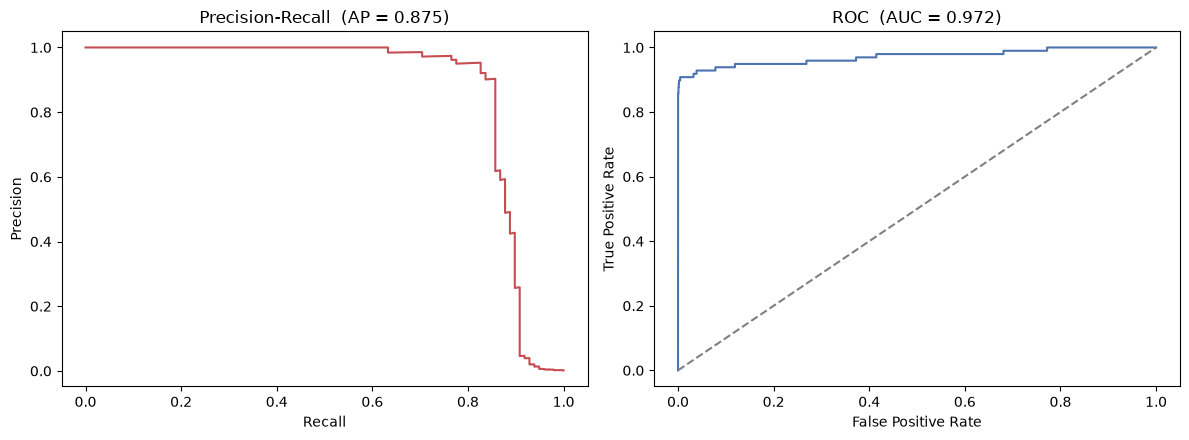

In [9]:
supervised = ["logreg", "logreg_smote", "lightgbm", "xgboost"]
headline = max(supervised, key=lambda k: evaluation.average_precision_score(y_val, val_scores[k]))
print("Headline model (best validation PR-AUC):", MODEL_LABELS[headline])
plotting.plot_pr_roc(y_test, test_scores[headline]); plt.show()

## 9. Probability calibration

The decision threshold is a probability cut-off, so the probabilities must mean what they say.
We calibrate the headline model on the validation split and check the reliability curve + Brier
score on test.

Brier score (test): 0.00037


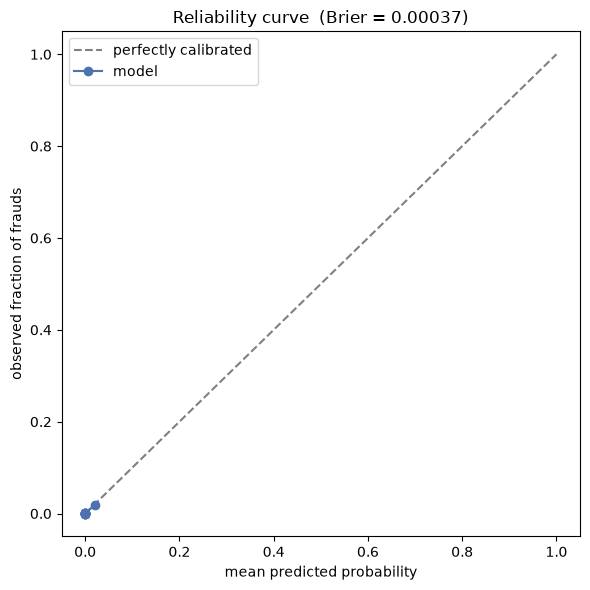

In [10]:
calibrated = calibration.calibrate(fitted[headline], X_val, y_val, cfg)
cal_val  = calibrated.predict_proba(X_val)[:, 1]
cal_test = calibrated.predict_proba(X_test)[:, 1]
brier = calibration.brier(y_test, cal_test)
frac_pos, mean_pred = calibration.reliability(y_test, cal_test)
print(f"Brier score (test): {brier:.5f}")
plotting.plot_reliability(frac_pos, mean_pred, brier); plt.show()

## 10. Choosing a threshold that matches the business cost

A missed fraud costs ~100x a false alarm. We pick the cost-minimising threshold **on the
validation split** (never on test), then apply it once to test.

Cost-optimal threshold = 0.006  (C_FN=100, C_FP=1), chosen on validation


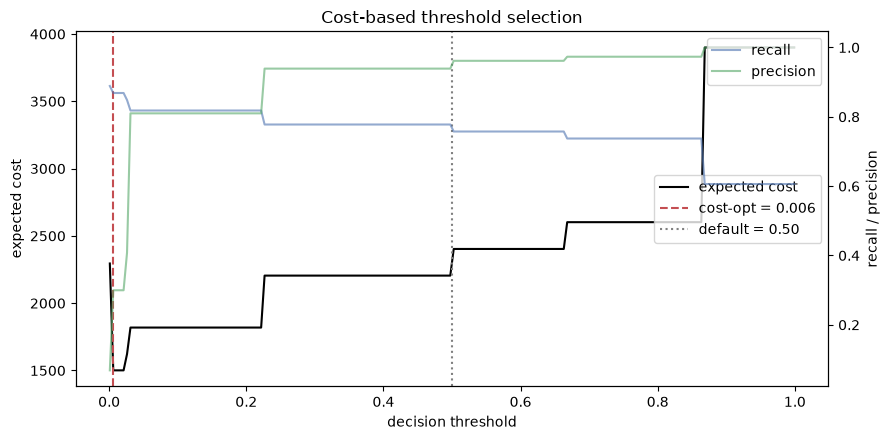


Test @ 0.50          : recall=0.827  precision=0.931
Test @ cost-optimal  : recall=0.898  precision=0.281


In [11]:
grid = threshold.threshold_grid(cfg)
curve = threshold.cost_curve(y_val, cal_val, grid, cfg.cost.c_fn, cfg.cost.c_fp)
print(f"Cost-optimal threshold = {curve.best_threshold:.3f}  "
      f"(C_FN={cfg.cost.c_fn:.0f}, C_FP={cfg.cost.c_fp:.0f}), chosen on validation")
plotting.plot_cost_curve(curve); plt.show()

at = evaluation.metric_row(y_test, cal_test, threshold=curve.best_threshold)
at_half = evaluation.metric_row(y_test, cal_test, threshold=0.5)
print(f"\nTest @ 0.50          : recall={at_half['recall']:.3f}  precision={at_half['precision']:.3f}")
print(f"Test @ cost-optimal  : recall={at['recall']:.3f}  precision={at['precision']:.3f}")

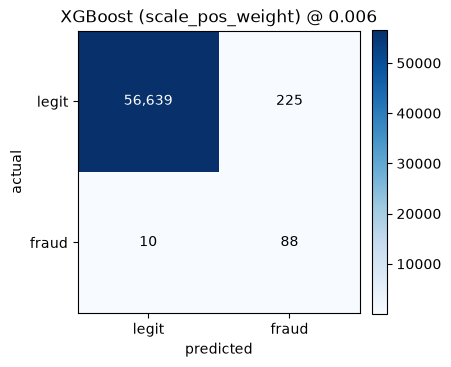

In [12]:
preds = (cal_test >= curve.best_threshold).astype(int)
plotting.plot_confusion(y_test, preds, f"{MODEL_LABELS[headline]} @ {curve.best_threshold:.3f}")
plt.show()

## 11. What is the model looking at? (feature importance)

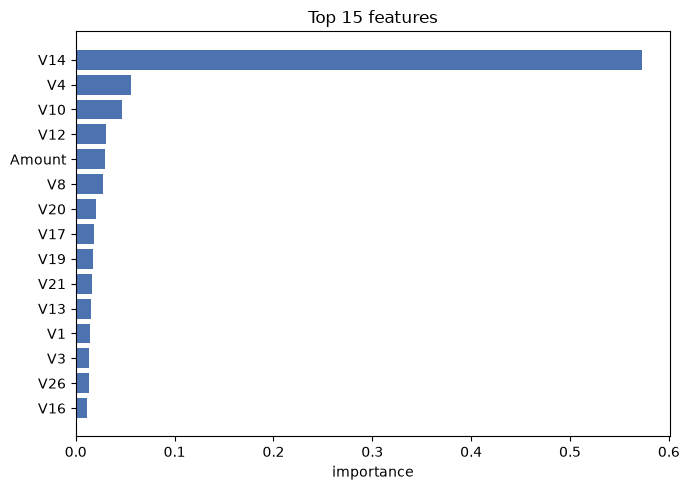

In [13]:
model = fitted[headline]
if hasattr(model, "feature_importances_"):
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    plotting.plot_feature_importance(imp); plt.show()
else:
    print(f"{MODEL_LABELS[headline]} has no feature_importances_.")

## 12. Takeaways

- **Validate honestly.** SMOTE-before-split inflates every metric to ~0.99 fiction; the same
  model evaluated correctly is far more modest.
- **Use PR-AUC, not accuracy or ROC-AUC.** At 0.17% positives, ROC-AUC stays high for useless
  models; PR-AUC and its bootstrap CI tell the real story.
- **Imbalance handling is model-specific.** XGBoost benefits from a large `scale_pos_weight`;
  LightGBM is *destabilised* by it and ranks best with default weighting. Cargo-culting one
  recipe across models is a mistake.
- **The threshold is a business lever**, chosen on validation against an explicit cost — not
  left at 0.5.

The tuned, fully-reported run (with hyper-parameter search) is produced by `make train`, which
writes `artifacts/metrics.json` and the figures referenced in the README.